In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv("C:/Users/Mohan/Documents/Candy/data/version_1/Candy_Products.csv")


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Division      15 non-null     str    
 1   Product Name  15 non-null     str    
 2   Factory       15 non-null     str    
 3   Product ID    15 non-null     str    
 4   Unit Price    15 non-null     float64
 5   Unit Cost     15 non-null     float64
dtypes: float64(2), str(4)
memory usage: 852.0 bytes


In [4]:
df["Division"]= df["Division"].astype("string")
df["Product Name"] = df["Product Name"].astype("string")
df["Factory"] = df["Factory"].astype("string")
df["Product ID"] = df["Product ID"].astype("string")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Division      15 non-null     string 
 1   Product Name  15 non-null     string 
 2   Factory       15 non-null     string 
 3   Product ID    15 non-null     string 
 4   Unit Price    15 non-null     float64
 5   Unit Cost     15 non-null     float64
dtypes: float64(2), string(4)
memory usage: 852.0 bytes


In [6]:
sm = df["Unit Cost"] / df["Unit Price"]

df1 = pd.DataFrame({
    "Unit Cost": df["Unit Cost"],
    "Unit Price": df["Unit Price"],
    "Ratio (Cost/Price)": sm
})

df1

,Unit Cost,Unit Price,Ratio (Cost/Price)
0,1.00,3.49,0.286533
1,1.20,3.60,0.333333
2,1.10,3.60,0.305556
3,1.14,3.25,0.350769
4,1.30,3.75,0.346667
5,0.75,1.99,0.376884
6,0.80,1.50,0.533333
7,0.80,1.50,0.533333
8,0.90,1.50,0.600000
9,1.50,3.75,0.400000


<Axes: >

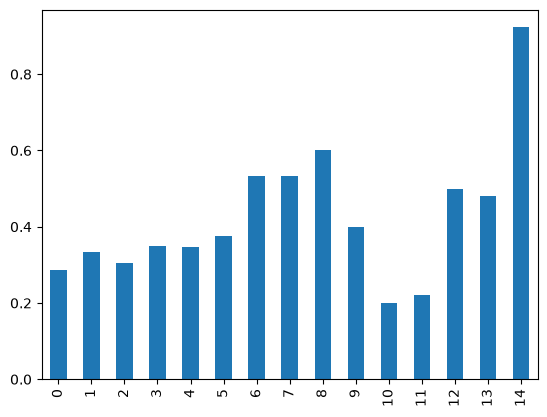

In [7]:
sm.plot(kind='bar')

# one hot encoding

In [8]:
df["Unit Price"].skew()

np.float64(2.84087408040907)

In [9]:
import pandas as pd

df_encoded = pd.get_dummies(df, columns=["Division","Factory"])

In [10]:
df_encoded["Unit Price"]= np.sqrt(df_encoded["Unit Price"])
df_encoded["Unit Cost"]=np.sqrt(df_encoded["Unit Cost"])

<Axes: >

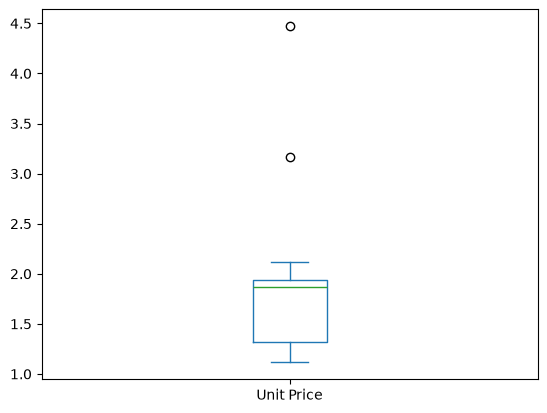

In [11]:
df_encoded["Unit Price"].plot(kind="box")

In [12]:
df_encoded["Unit Price"].skew()

np.float64(2.070443964349331)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded["Unit Price"] = scaler.fit_transform(df_encoded[["Unit Price"]])
df_encoded["Unit Cost"] = scaler.fit_transform(df_encoded[["Unit Cost"]])

In [14]:
df_encoded.head()

,Product Name,Product ID,Unit Price,Unit Cost,Division_Chocolate,Division_Other,Division_Sugar,Factory_Lot's O' Nuts,Factory_Secret Factory,Factory_Sugar Shack,Factory_The Other Factory,Factory_Wicked Choccy's
0,Wonka Bar - Nutty Crunch Surprise,CHO-NUT-13000,-0.085980,-0.382520,True,False,False,True,False,False,False,False
1,Wonka Bar - Fudge Mallows,CHO-FUD-51000,-0.051024,-0.214715,True,False,False,True,False,False,False,False
2,Wonka Bar -Scrumdiddlyumptious,CHO-SCR-58000,-0.051024,-0.296708,True,False,False,True,False,False,False,False
3,Wonka Bar - Milk Chocolate,CHO-MIL-31000,-0.164213,-0.263481,True,False,False,False,False,False,False,True
4,Wonka Bar - Triple Dazzle Caramel,CHO-TRI-54000,-0.004206,-0.136074,True,False,False,False,False,False,False,True


In [15]:
import plotly.express as px

fig = px.box(
    df,
    y="Unit Price",
    points="outliers",
    title="Unit Price Distribution"
)

fig.update_layout(
    template="plotly_white",
    yaxis_title="Unit Price",
    xaxis_title="",
    width=1000,
    height=600
)

fig.show()

In [16]:
df_encoded.to_csv("C:/Users/Mohan/Documents/Candy/data/version_2/Candy_Products.csv",index=False)